In [39]:
%pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn sqlalchemy pymysql --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from collections import Counter
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [41]:
# koneksi ke database mysql
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = int(os.getenv('DB_PORT', '3306'))
DB_USER     = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME     = os.getenv('DB_NAME', 'datawarehouse_om')

# engine koneksi (SQLAlchemy)
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print(f"Koneksi ke database siap: {DB_HOST}:{DB_PORT}/{DB_NAME}")

Koneksi ke database siap: localhost:3306/datawarehouse_om


In [42]:
query = """
    SELECT
        f.fact_id,
        f.severity,
        t.month,
        m.scope_of_work,
        s.city,
        s.site_code
    FROM fact_maintenance_activity f
    JOIN dim_time             t  ON f.time_id        = t.time_id
    JOIN dim_maintenance_type m  ON f.maintenance_id = m.maintenance_id
    JOIN dim_site             s  ON f.site_id        = s.site_id
        AND s.is_current = 1
"""

df = pd.read_sql(query, con=engine)
print(f"Data berhasil diambil: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(df.head(3))

# Simpan salinan data asli (sebelum encoding) untuk keperluan export
df_raw = df.copy()

Data berhasil diambil: 52,427 baris × 6 kolom
   fact_id severity  month scope_of_work                 city   site_code
0     1421    minor      1            q2  kabupaten bondowoso  bdw-07-001
1     5963    minor      2            b4  kabupaten bondowoso  bdw-07-001
2     9883    minor      3           vw2  kabupaten bondowoso  bdw-07-001


In [43]:
# DATA PREPARATION
NUM_COLS = ['month']
for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Tipe data setelah konversi:")
print(df.dtypes)
print(f"\nNilai null per kolom:")
print(df.isnull().sum())

Tipe data setelah konversi:
fact_id           int64
severity         object
month             int64
scope_of_work    object
city             object
site_code        object
dtype: object

Nilai null per kolom:
fact_id          0
severity         0
month            0
scope_of_work    0
city             0
site_code        0
dtype: int64


In [44]:
# definisi fitur
FEATURE_COLS = [
    'month',           # waktu pelaksanaan maintenance
    'scope_of_work',   # detail jenis pekerjaan maintenance
    'city',            # kota lokasi site
    'site_code',       # kode site 
]
TARGET_COL = 'severity'

# encoding variabel kategorikal
CAT_COLS = ['scope_of_work', 'city', 'site_code']
label_encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str).str.strip().str.lower())
    label_encoders[col] = le
    print(f"  Encoded '{col}' → {len(le.classes_)} kelas unik")

  Encoded 'scope_of_work' → 52 kelas unik
  Encoded 'city' → 31 kelas unik
  Encoded 'site_code' → 8033 kelas unik


In [45]:
# distribusi kelas target
sev_counts = df['severity'].value_counts()
total      = len(df)

print("DISTRIBUSI TARGET (SEVERITY)")
for label, count in sev_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:<8}: {count:>6} ({pct:5.1f}%)  {bar}")

ratio = sev_counts['minor'] / sev_counts['major']
print(f"\nImbalance Ratio (minor:major) = {ratio:.2f}:1")
print("Data tidak seimbang")

DISTRIBUSI TARGET (SEVERITY)
  minor   :  42796 ( 81.6%)  ████████████████████████████████████████
  major   :   9631 ( 18.4%)  █████████

Imbalance Ratio (minor:major) = 4.44:1
Data tidak seimbang


In [46]:
# Encode target: minor = 0, major = 1
df['severity_encoded'] = df[TARGET_COL].str.strip().str.lower().map({'minor': 0, 'major': 1})

X = df[FEATURE_COLS].copy()
y = df['severity_encoded'].copy()

print(f"Fitur  (X) : {X.shape}")
print(f"Target (y) : {y.shape} →  0 = minor, 1 = major")

Fitur  (X) : (52427, 4)
Target (y) : (52427,) →  0 = minor, 1 = major


In [47]:
# split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y     
)

print("HASIL SPLIT DATA")
print(f"  Training (80%): {len(X_train):>6} baris")
print(f"  Testing  (20%): {len(X_test):>6} baris")
print(f"  Total data    : {len(X):>6} baris")
print()
print("Distribusi Training (sebelum Under Sampling):")
for label, count in sorted(Counter(y_train).items()):
    name = 'major' if label == 1 else 'minor'
    print(f"    {name}: {count}")

HASIL SPLIT DATA
  Training (80%):  41941 baris
  Testing  (20%):  10486 baris
  Total data    :  52427 baris

Distribusi Training (sebelum Under Sampling):
    minor: 34236
    major: 7705


In [48]:
# RANDOM UNDER SAMPLING
rus = RandomUnderSampler(sampling_strategy=1, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print("DISTRIBUSI SETELAH RANDOM UNDER SAMPLING (Data Training)")
before = Counter(y_train)
after  = Counter(y_train_res)

print(f"  {'Kelas':<10} {'Sebelum':>10} {'Sesudah':>10}  {'  Pengurangan':>14}")
print(f"  {'-'*50}")
for label in sorted(after.keys()):
    name = 'major' if label == 1 else 'minor'
    diff = before[label] - after[label]
    sign = '-' if diff > 0 else '+'
    print(f"  {name:<10} {before[label]:>10} {after[label]:>10}  {sign}{abs(diff):>13}")

ratio_after = after[0] / after[1]
print(f"\nImbalance ratio setelah RUS : {ratio_after}:1")
print(f"Total training setelah RUS  : {len(y_train_res)} baris")
print()
print("Random Under Sampling berhasil menyeimbangkan data")

DISTRIBUSI SETELAH RANDOM UNDER SAMPLING (Data Training)
  Kelas         Sebelum    Sesudah     Pengurangan
  --------------------------------------------------
  minor           34236       7705  -        26531
  major            7705       7705  +            0

Imbalance ratio setelah RUS : 1.0:1
Total training setelah RUS  : 15410 baris

Random Under Sampling berhasil menyeimbangkan data


In [49]:
# MODELING
# CV K-FOLD (k=10)
from imblearn.pipeline import Pipeline as ImbPipeline

cv_pipeline = ImbPipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('rf',  RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            ))
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_validate(
    cv_pipeline, X, y,
    cv      = skf,
    scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    n_jobs  = -1,
    verbose = 0
)

print("HASIL CROSS-VALIDATION (10-Fold)\n")

metrics = [
    ('Accuracy',  'test_accuracy'),
    ('Precision', 'test_precision_weighted'),
    ('Recall',    'test_recall_weighted'),
    ('F1-Score',  'test_f1_weighted'),
]

header = "          "
for i in range(1, 11):
    header += f"F{i:2}      "
header += "Mean     Std"
print(header)

for label, key in metrics:
    vals = cv_results[key]
    mean_val = vals.mean()
    std_val = vals.std()
    
    row = f"{label:<10}"
    for v in vals:
        row += f"{v:8.4f}"
    row += f"{mean_val:8.4f}{std_val:8.4f}"
    print(row)

print(f"\nCV selesai, Akurasi rata-rata: {cv_results['test_accuracy'].mean()*100:.2f}% ± {cv_results['test_accuracy'].std()*100:.2f}%")

HASIL CROSS-VALIDATION (10-Fold)

          F 1      F 2      F 3      F 4      F 5      F 6      F 7      F 8      F 9      F10      Mean     Std
Accuracy    0.7011  0.6859  0.6918  0.6933  0.7019  0.7095  0.7078  0.6908  0.6864  0.6890  0.6957  0.0082
Precision   0.8106  0.7962  0.8045  0.8104  0.8113  0.8135  0.8157  0.8046  0.8068  0.8056  0.8079  0.0053
Recall      0.7011  0.6859  0.6918  0.6933  0.7019  0.7095  0.7078  0.6908  0.6864  0.6890  0.6957  0.0082
F1-Score    0.7326  0.7188  0.7244  0.7261  0.7332  0.7396  0.7384  0.7236  0.7202  0.7223  0.7279  0.0071

CV selesai, Akurasi rata-rata: 69.57% ± 0.82%


In [50]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_res, y_train_res)
print("Model Random Forest dilatih\n")

# prediksi data testing (ori, tanpa under sampling)
y_pred       = rf_final.predict(X_test)
y_pred_proba = rf_final.predict_proba(X_test)

print(f"Prediksi selesai untuk {len(y_test)} data testing.")

Model Random Forest dilatih

Prediksi selesai untuk 10486 data testing.


In [51]:
# EVALUASI MODEL
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')  
rec  = recall_score(y_test, y_pred, average='weighted')     
f1   = f1_score(y_test, y_pred, average='weighted')         

# Untuk detail per kelas
prec_major = precision_score(y_test, y_pred, pos_label=1)
rec_major  = recall_score(y_test, y_pred, pos_label=1)
f1_major   = f1_score(y_test, y_pred, pos_label=1)

prec_minor = precision_score(y_test, y_pred, pos_label=0)
rec_minor  = recall_score(y_test, y_pred, pos_label=0)
f1_minor   = f1_score(y_test, y_pred, pos_label=0)

print("HASIL EVALUASI MODEL RANDOM FOREST + RUS")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print()
print("Classification Report :")
print(classification_report(y_test, y_pred, target_names=['minor', 'major']))

HASIL EVALUASI MODEL RANDOM FOREST + RUS
  Accuracy  : 0.6971  (69.71%)
  Precision : 0.8117  (81.17%)
  Recall    : 0.6971  (69.71%)
  F1-Score  : 0.7294  (72.94%)

Classification Report :
              precision    recall  f1-score   support

       minor       0.92      0.69      0.79      8560
       major       0.34      0.72      0.47      1926

    accuracy                           0.70     10486
   macro avg       0.63      0.71      0.63     10486
weighted avg       0.81      0.70      0.73     10486



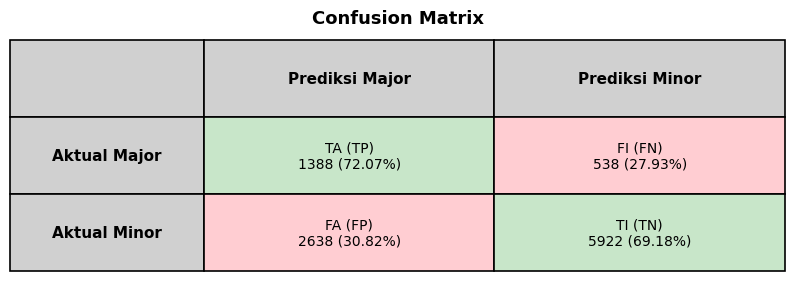

In [52]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

TP = cm[1][1]  # Aktual Major, Prediksi Major
FP = cm[0][1]  # Aktual Minor, Prediksi Major
TN = cm[0][0]  # Aktual Minor, Prediksi Minor
FN = cm[1][0]  # Aktual Major, Prediksi Minor

total_major_actual = TP + FN
total_minor_actual = TN + FP

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table_data = [
    ['',              'Prediksi Major',               'Prediksi Minor'             ],
    ['Aktual Major',  f'TA (TP)\n{TP} ({TP/total_major_actual*100:.2f}%)', f'FI (FN)\n{FN} ({FN/total_major_actual*100:.2f}%)'],
    ['Aktual Minor',  f'FA (FP)\n{FP} ({FP/total_minor_actual*100:.2f}%)', f'TI (TN)\n{TN} ({TN/total_minor_actual*100:.2f}%)'],
]

table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center',
    bbox=[0, 0, 1, 1] 
)

table.auto_set_font_size(False)
table.set_fontsize(11)

col_widths = [0.25, 0.375, 0.375]
for (row, col), cell in table.get_celld().items():
    cell.set_width(col_widths[col])
    cell.set_height(0.33)
    cell.set_edgecolor('black')
    cell.set_linewidth(1.2)

    if row == 0 or col == 0:
        cell.set_facecolor('#D0D0D0')
        cell.set_text_props(fontweight='bold', fontsize=11)
    elif row == 1 and col == 1:
        cell.set_facecolor('#C8E6C9')
        cell.set_text_props(fontsize=10)
    elif row == 2 and col == 2:
        cell.set_facecolor('#C8E6C9')
        cell.set_text_props(fontsize=10)
    else:
        cell.set_facecolor('#FFCDD2')
        cell.set_text_props(fontsize=10)

ax.set_title('Confusion Matrix',
             fontsize=13, fontweight='bold', pad=12)
plt.show()

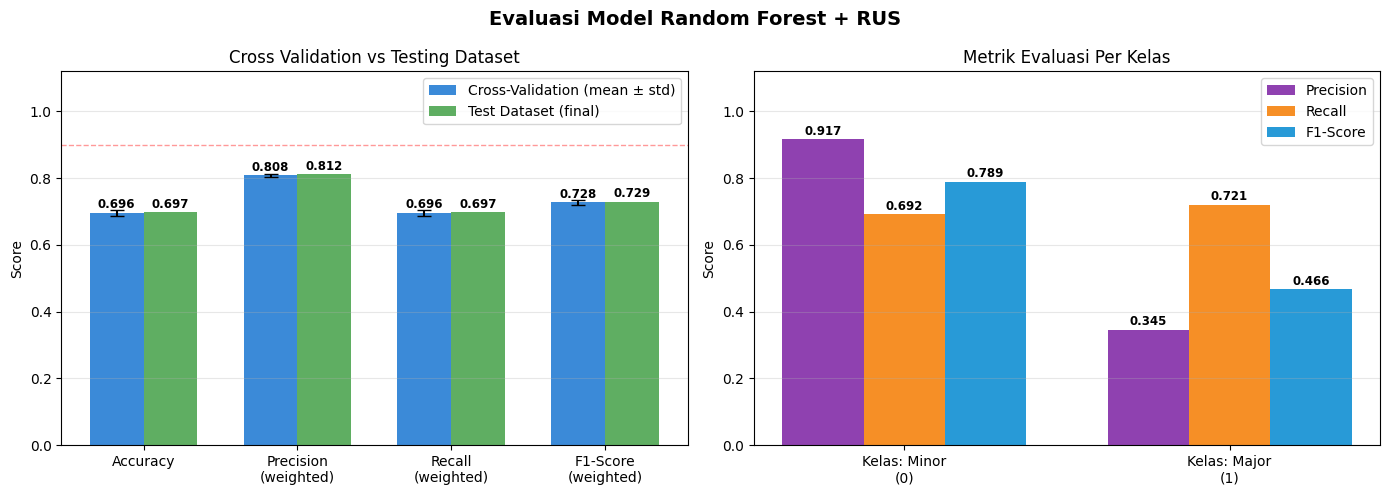

In [53]:
# CV + DATA TESTING
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluasi Model Random Forest + RUS', fontsize=14, fontweight='bold')

# panel kiri
ax1 = axes[0]
metrics_names  = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1-Score\n(weighted)']
cv_means  = [
    cv_results['test_accuracy'].mean(),
    cv_results['test_precision_weighted'].mean(),
    cv_results['test_recall_weighted'].mean(),
    cv_results['test_f1_weighted'].mean(),
]
cv_stds   = [
    cv_results['test_accuracy'].std(),
    cv_results['test_precision_weighted'].std(),
    cv_results['test_recall_weighted'].std(),
    cv_results['test_f1_weighted'].std(),
]
test_vals  = [acc, prec, rec, f1]

x      = np.arange(len(metrics_names))
width  = 0.35
colors_bar = ['#1976D2', '#43A047']

bars1 = ax1.bar(x - width/2, cv_means, width, yerr=cv_stds, capsize=5,
                label='Cross-Validation (mean ± std)', color=colors_bar[0], alpha=0.85)
bars2 = ax1.bar(x + width/2, test_vals, width,
                label='Test Dataset (final)', color=colors_bar[1], alpha=0.85)

for bar, val in zip(bars1, cv_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar, val in zip(bars2, test_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax1.set_ylim(0, 1.12)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.set_ylabel('Score')
ax1.set_title('Cross Validation vs Testing Dataset')
ax1.legend()
ax1.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, linewidth=1, label='Target ≥ 0.90')
ax1.grid(axis='y', alpha=0.3)

# panel kanan
ax2 = axes[1]
kelas      = ['minor', 'major']
prec_vals  = [prec_minor, prec_major]
rec_vals   = [rec_minor,  rec_major]
f1_vals    = [f1_minor,   f1_major]

x2    = np.arange(len(kelas))
w2    = 0.25
ax2.bar(x2 - w2, prec_vals, w2, label='Precision', color='#7B1FA2', alpha=0.85)
ax2.bar(x2,      rec_vals,  w2, label='Recall',    color='#F57C00', alpha=0.85)
ax2.bar(x2 + w2, f1_vals,   w2, label='F1-Score',  color='#0288D1', alpha=0.85)

for vals, offset in [(prec_vals, -w2), (rec_vals, 0), (f1_vals, w2)]:
    for i, v in enumerate(vals):
        ax2.text(i + offset, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.set_ylim(0, 1.12)
ax2.set_xticks(x2)
ax2.set_xticklabels(['Kelas: Minor\n(0)', 'Kelas: Major\n(1)'])
ax2.set_ylabel('Score')
ax2.set_title('Metrik Evaluasi Per Kelas')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# feature importance
fi_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("FEATURE IMPORTANCE")
print(f"{'-'*55}")
for i, row in fi_df.iterrows():
    bar = "█" * int(row['Importance'] * 60)
    print(f"{i+1:2}. {row['Feature']:<15} {row['Importance']:.4f}  {bar}")

FEATURE IMPORTANCE
-------------------------------------------------------
 1. site_code       0.5696  ██████████████████████████████████
 2. scope_of_work   0.1919  ███████████
 3. month           0.1316  ███████
 4. city            0.1069  ██████


In [55]:
# insights
top1 = fi_df.iloc[0]

print("KEY INSIGHTS - FINAL RESULTS")
print(f"{'-'*80}")
print(f"1) Fitur paling berpengaruh : {top1['Feature']} (importance: {top1['Importance']:.4f})")
print(f"2) Fitur yang digunakan     : {FEATURE_COLS}")
print(f"3) Akurasi model            : {acc*100:.2f}%")
print(f"   CV 10-Fold               : {cv_results['test_accuracy'].mean()*100:.2f}% ± {cv_results['test_accuracy'].std()*100:.2f}%")
print(f"4) Penanganan imbalance     : Random Under Sampling (rasio 1:1 pada training)")
print(f"                              Sebelum RUS — minor: {Counter(y_train)[0]}, major: {Counter(y_train)[1]}")
print(f"                              Sesudah RUS — minor: {Counter(y_train_res)[0]}, major: {Counter(y_train_res)[1]}")
print()
if acc >= 0.90:
    print("Status: SANGAT BAIK — Accuracy ≥ 90%")
elif acc >= 0.80:
    print("Status: BAIK — Accuracy ≥ 80%")
else:
    print("Status: CUKUP — Accuracy < 80%")
print("Data Mining Process Complete!")

KEY INSIGHTS - FINAL RESULTS
--------------------------------------------------------------------------------
1) Fitur paling berpengaruh : site_code (importance: 0.5696)
2) Fitur yang digunakan     : ['month', 'scope_of_work', 'city', 'site_code']
3) Akurasi model            : 69.71%
   CV 10-Fold               : 69.57% ± 0.82%
4) Penanganan imbalance     : Random Under Sampling (rasio 1:1 pada training)
                              Sebelum RUS — minor: 34236, major: 7705
                              Sesudah RUS — minor: 7705, major: 7705

Status: CUKUP — Accuracy < 80%
Data Mining Process Complete!


In [56]:
# Persiapan data untuk export ke dashboard
df_predict = X_test.copy()
df_predict['actual_severity']    = y_test.values
df_predict['predicted_severity'] = y_pred
df_predict['confidence_minor']   = y_pred_proba[:, 0]
df_predict['confidence_major']   = y_pred_proba[:, 1]

# Decode kolom yang di-encode kembali ke nilai asli
for col in CAT_COLS:
    le = label_encoders[col]
    df_predict[col] = le.inverse_transform(df_predict[col].astype(int))

# Decode label target ke teks
df_predict['actual_severity']    = df_predict['actual_severity'].map({0: 'Minor', 1: 'Major'})
df_predict['predicted_severity'] = df_predict['predicted_severity'].map({0: 'Minor', 1: 'Major'})

# Tambah kolom confidence_score (confidence dari kelas yang diprediksi)
df_predict['confidence_score'] = df_predict.apply(
    lambda r: r['confidence_major'] if r['predicted_severity'] == 'Major' else r['confidence_minor'], axis=1
)

# Tambah kolom top_factor dari feature importance
fi_sorted = fi_df['Feature'].tolist()  # sudah urut dari yang terpenting
df_predict['top_factor_1'] = fi_sorted[0]
df_predict['top_factor_2'] = fi_sorted[1]

# Rapikan nama kolom untuk kebutuhan dashboard
df_predict = df_predict.rename(columns={'city': 'kota_kabupaten', 'site_code': 'nama_site'})

print("Data siap untuk dashboard:")
print(df_predict[['nama_site', 'kota_kabupaten', 'predicted_severity', 'confidence_score', 'top_factor_1', 'top_factor_2']].head(10))
print(f"Total records : {len(df_predict)}")
print(f"Kolom tersedia: {list(df_predict.columns)}")

Data siap untuk dashboard:
        nama_site      kota_kabupaten predicted_severity  confidence_score  \
31680  njk-07-088   kabupaten nganjuk              Minor              1.00   
10540  jmr-07-088    kabupaten jember              Minor              1.00   
45062  sda-07-279  kabupaten sidoarjo              Major              0.91   
42409  sby/07/240       kota surabaya              Major              0.95   
37454  sby-07-021       kota surabaya              Minor              0.65   
31137  njk-07-031   kabupaten nganjuk              Minor              0.92   
48489  tbn-07-022     kabupaten tuban              Major              0.78   
42789  sby/07/587       kota surabaya              Minor              0.64   
26680  mjy-07-049     kota/kab madiun              Minor              1.00   
42507  sby/07/371       kota surabaya              Major              0.77   

      top_factor_1   top_factor_2  
31680    site_code  scope_of_work  
10540    site_code  scope_of_work  
45062 

In [57]:
# Export CSV untuk dashboard
cols_export = [
    'nama_site',
    'kota_kabupaten',
    'month',
    'scope_of_work',
    'actual_severity',
    'predicted_severity',
    'confidence_score',
    'confidence_minor',
    'confidence_major',
    'top_factor_1',
    'top_factor_2',
]
df_export = df_predict[[c for c in cols_export if c in df_predict.columns]]

# Rapihin tipe data sebelum export
df_export = df_export.copy()
df_export['month']            = df_export['month'].astype(int)
df_export['confidence_score'] = df_export['confidence_score'].astype(float)
df_export['confidence_minor'] = df_export['confidence_minor'].astype(float)
df_export['confidence_major'] = df_export['confidence_major'].astype(float)

df_export.to_csv('hasil_prediksi_severity.csv', index=False)
print('✓ Ekspor berhasil: hasil_prediksi_severity.csv')
print(f'  Total rows: {len(df_export)}')
print(f'  Kolom     : {list(df_export.columns)}')
print(df_export.dtypes)
print(df_export.head(3).to_string())

✓ Ekspor berhasil: hasil_prediksi_severity.csv
  Total rows: 10486
  Kolom     : ['nama_site', 'kota_kabupaten', 'month', 'scope_of_work', 'actual_severity', 'predicted_severity', 'confidence_score', 'confidence_minor', 'confidence_major', 'top_factor_1', 'top_factor_2']
nama_site              object
kota_kabupaten         object
month                   int64
scope_of_work          object
actual_severity        object
predicted_severity     object
confidence_score      float64
confidence_minor      float64
confidence_major      float64
top_factor_1           object
top_factor_2           object
dtype: object
        nama_site      kota_kabupaten  month scope_of_work actual_severity predicted_severity  confidence_score  confidence_minor  confidence_major top_factor_1   top_factor_2
31680  njk-07-088   kabupaten nganjuk      1            a5           Minor              Minor              1.00              1.00              0.00    site_code  scope_of_work
10540  jmr-07-088    kabupaten j